In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("knn.csv")

In [47]:
df.head()

,Weight(x2),Height(y2),Class
0,51,167,Underweight
1,66,177,Normal
2,75,169,Overweight
3,69,176,Normal
4,50,173,Underweight


In [48]:
df.tail()

,Weight(x2),Height(y2),Class
20,53,170,Underweight
21,74,182,Normal
22,72,175,Overweight
23,53,163,Normal
24,55,180,Underweight


In [49]:
df.describe()

,Weight(x2),Height(y2)
count,25.00000,25.000000
mean,64.44000,172.480000
std,9.62237,6.532738
min,50.00000,162.000000
25%,57.00000,168.000000
50%,65.00000,173.000000
75%,72.00000,178.000000
max,82.00000,183.000000


In [50]:
df.isna().sum()

Weight(x2)    0
Height(y2)    0
Class         0
dtype: int64

In [51]:
df.shape

(25, 3)

In [52]:
df.columns

Index(['Weight(x2)', 'Height(y2)', 'Class'], dtype='object')

In [53]:
## how to convert categorical data into numerical data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [54]:
df['Class'] = le.fit_transform(df['Class'])

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Weight(x2)  25 non-null     int64
 1   Height(y2)  25 non-null     int64
 2   Class       25 non-null     int64
dtypes: int64(3)
memory usage: 732.0 bytes


<Axes: xlabel='Weight(x2)', ylabel='count'>

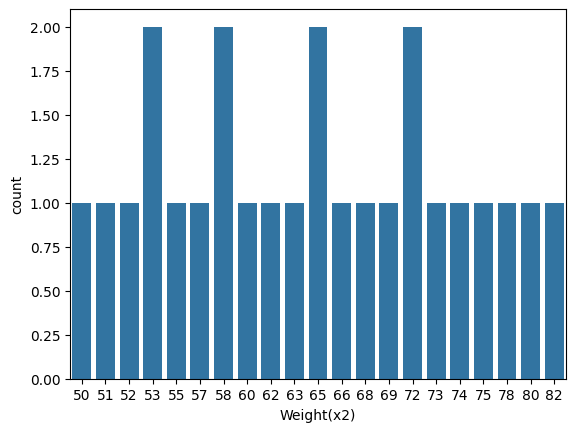

In [56]:
sns.countplot(x='Weight(x2)',data = df)

<Axes: xlabel='Height(y2)', ylabel='count'>

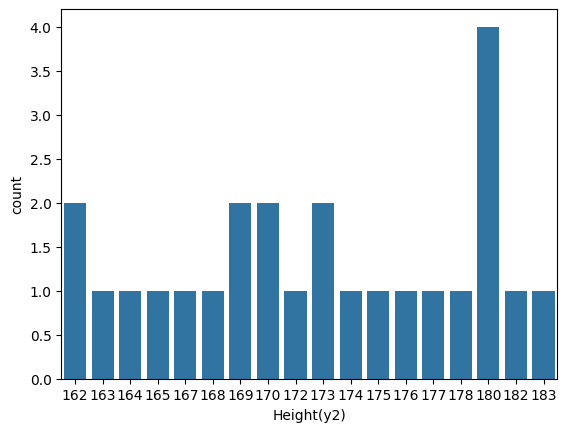

In [57]:
sns.countplot(x='Height(y2)',data = df)

<Axes: xlabel='Weight(x2)', ylabel='Count'>

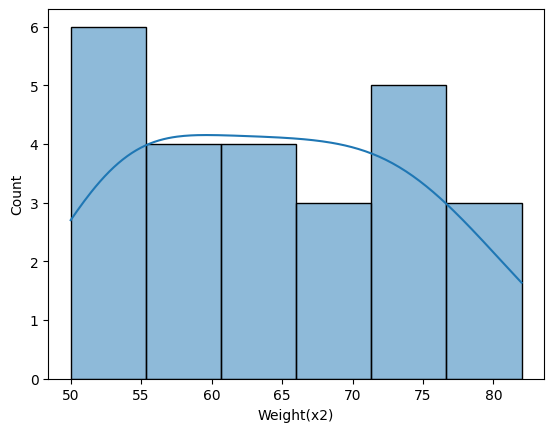

In [58]:
sns.histplot(x = "Weight(x2)",kde = True , data = df)

<Axes: xlabel='Height(y2)', ylabel='Count'>

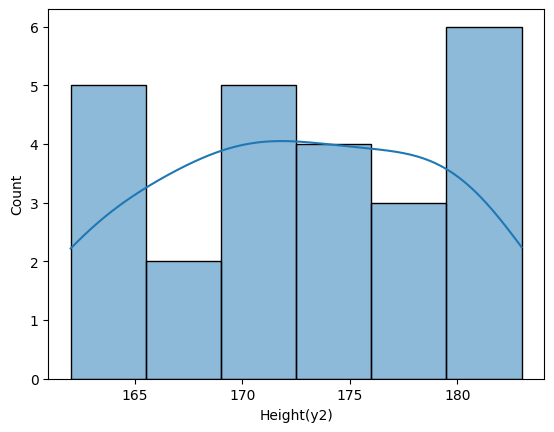

In [59]:
sns.histplot(x = "Height(y2)",kde = True , data = df)

In [60]:
df.corr()

,Weight(x2),Height(y2),Class
Weight(x2),1.000000,0.010420,-0.362219
Height(y2),0.010420,1.000000,0.184649
Class,-0.362219,0.184649,1.000000


<Axes: >

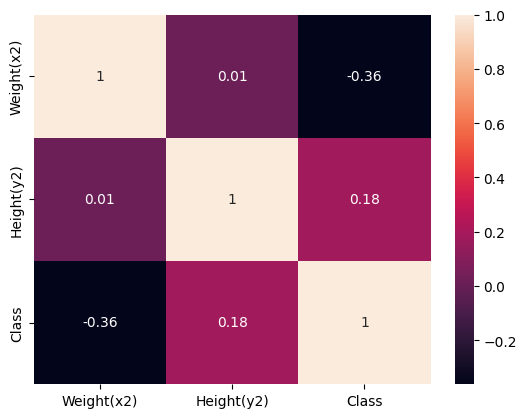

In [61]:
sns.heatmap(df.corr(),annot= True)

In [62]:
df.head()

,Weight(x2),Height(y2),Class
0,51,167,2
1,66,177,0
2,75,169,1
3,69,176,0
4,50,173,2


In [63]:
X = df[["Weight(x2)","Height(y2)"]]
y = df["Class"]

In [64]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [65]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [67]:
model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [68]:
model.score(X_test,y_test)

1.0

In [69]:
model.predict(X_test)

array([0, 0, 1, 2, 1])

In [70]:
y_pred = model.predict(X_test)

In [71]:
from sklearn.metrics import confusion_matrix,classification_report

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Confusion Matrix:
[[2 0 0]
 [0 2 0]
 [0 0 1]]


<Axes: >

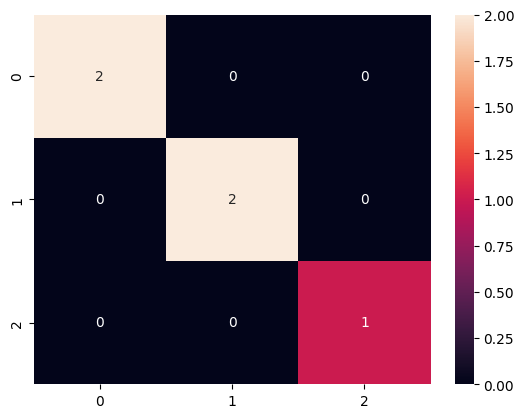

In [72]:
sns.heatmap(cm,annot = True )

In [73]:
sse = [] ## Sum of square error list form conversion
range=(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20)

In [74]:
for i in range:
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train,y_train)
  knn1=model.predict(X_test)
  sse.append(np.mean(knn1!=y_test))

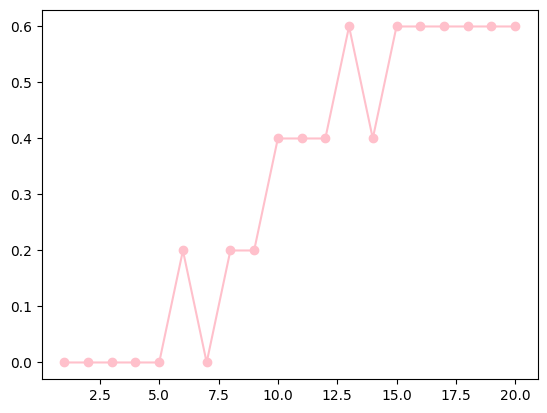

In [75]:
plt.plot(range,sse,marker='o',color='pink')